# Clasificación de zonas grises tributarias
## Estatuto Tributario Colombiano — detección automática de complejidad normativa

**JURISIN 2026** · Sofia Ocampo · socampoq@unal.edu.co

---

### Pregunta de investigación

> ¿Puede el texto legal, representado con TF-IDF, alimentar clasificadores automáticos que identifiquen las dimensiones de complejidad que generan *zonas grises* en el Estatuto Tributario Colombiano?

### Estructura de este notebook

| Sección | Experimento | Pregunta que responde |
|---------|------------|----------------------|
| 1 | **Baseline: LR independientes** | ¿Qué tan bien funciona el enfoque más simple? |
| 2 | **TextCNN con representación compartida** | ¿Un modelo más potente mejora los resultados? |
| 3 | **Cadenas de clasificadores con χ²** | ¿Modelar las dependencias entre etiquetas ayuda? |

**Argumento central:** en corpus legales pequeños, el cuello de botella no es la capacidad del modelo, sino la *estructura de las etiquetas*.

## Configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, time, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except ImportError:
    from keras.preprocessing.text import Tokenizer
    from keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='muted')
print('TF:', tf.__version__)

TF: 2.21.0


## Datos

**Corpus:** 169 artículos del Estatuto Tributario colombiano, anotados manualmente por expertos en derecho tributario.

**5 dimensiones de zona gris (etiquetas objetivo):**

| Dimensión | Descripción | Clases |
|-----------|-------------|--------|
| **Relevance** | ¿El artículo afecta la carga tributaria del contribuyente? | 0–1 |
| **Interpretability** | ¿Qué tan ambiguo es el lenguaje del artículo? | 0–3 |
| **Completeness** | ¿Faltan definiciones o remisiones necesarias? | 0–1 |
| **Differential Regime** | ¿Establece un régimen diferencial o excepción? | 0–1 |
| **Discretionality** | ¿Otorga discrecionalidad a la administración? | 0–1 |

**Reto:** corpus pequeño (135 train / 34 test), clases desbalanceadas, etiquetas interdependientes.

In [2]:
_root = r'c:\Users\Sofia\OneDrive - Universidad Nacional de Colombia\Documentos\GEFE\Detección de elusión fiscal\Tax Law Complexity\JURISIN 2026'
EXCEL_PATH = os.path.join(_root, '00_base.xlsx')

df = pd.read_excel(EXCEL_PATH, engine='openpyxl')
df = df[['Law', 'Article', 'Spanish text', 'Relevance', 'Interpretability',
         'Completeness', 'Differential Regime', 'Discretionality']].copy()
df.columns = ['law', 'article', 'text', 'relevance', 'interpretability',
              'completeness', 'differential_regime', 'discretionality']
df['text'] = df['text'].fillna('').str.strip()
df = df.dropna(subset=['relevance','interpretability','completeness',
                        'differential_regime','discretionality']).reset_index(drop=True)

LABELS = ['relevance', 'interpretability', 'completeness', 'differential_regime', 'discretionality']
print(f'Artículos: {len(df)} | Leyes: {df["law"].nunique()}')
print('\nDistribución de etiquetas:')
for col in LABELS:
    vc = df[col].value_counts().sort_index()
    print(f'  {col:25s}: {vc.to_dict()}')

Artículos: 169 | Leyes: 4

Distribución de etiquetas:
  relevance                : {0: 97, 1: 72}
  interpretability         : {1: 81, 2: 36, 3: 52}
  completeness             : {0: 122, 1: 47}
  differential_regime      : {0: 109, 1: 60}
  discretionality          : {0: 93, 1: 76}


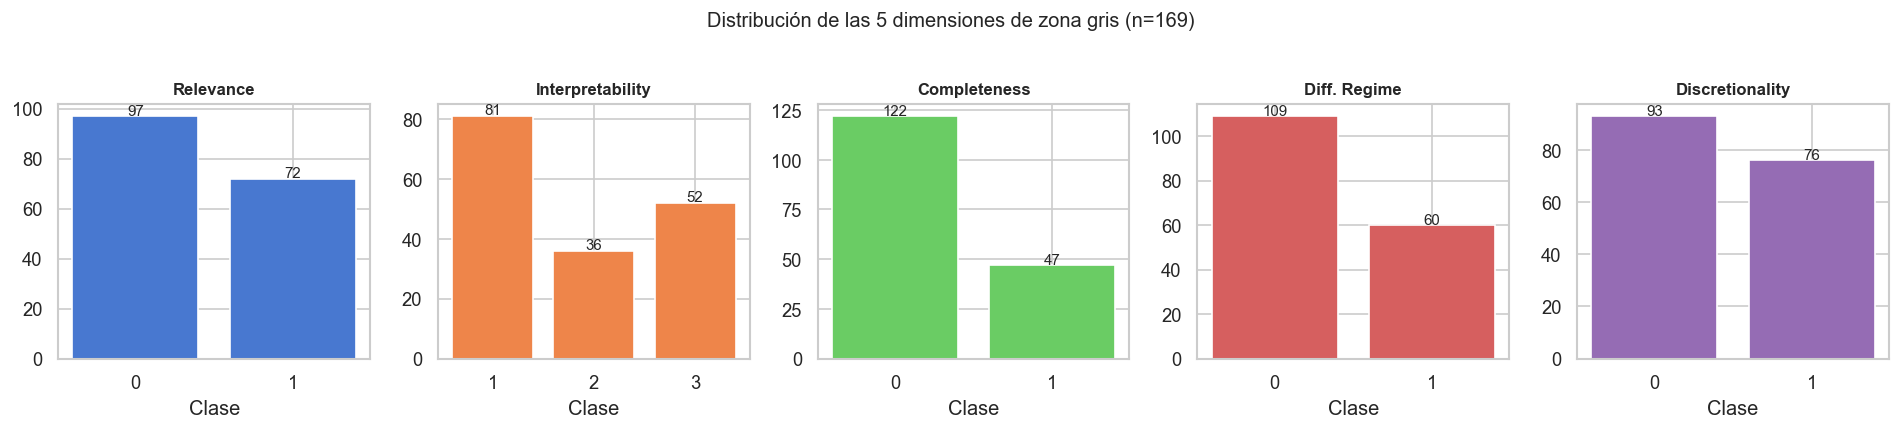

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
pal = sns.color_palette('muted', 5)
labels_short = ['Relevance', 'Interpretability', 'Completeness', 'Diff. Regime', 'Discretionality']
for ax, col, title, color in zip(axes, LABELS, labels_short, pal):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Clase')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.suptitle('Distribución de las 5 dimensiones de zona gris (n=169)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pres_distribucion.png', bbox_inches='tight')
plt.show()

## Representación del texto: TF-IDF

Cada artículo se convierte en un vector de pesos **TF-IDF** (Term Frequency – Inverse Document Frequency).

$$\text{tfidf}(t, d) = \underbrace{\frac{f_{t,d}}{\sum_k f_{k,d}}}_{\text{frecuencia en doc}} \times \underbrace{\log\frac{N}{|\{d: t \in d\}|}}_{\text{rareza global}}$$

**Configuración:** 3 000 features · bigramas `(1,2)` · `sublinear_tf=True` · `min_df=2`.

> **¿Por qué no embeddings?** Con 135 artículos de entrenamiento, la curva de aprendizaje muestra que incluso LR no satura — más parámetros añadirían varianza sin reducir sesgo.

In [4]:
# ── LabelEncoders por etiqueta ────────────────────────────────────────────────
label_encoders = {}
Y_all = {}
for col in LABELS:
    le = LabelEncoder()
    Y_all[col] = le.fit_transform(df[col].values.ravel())
    label_encoders[col] = le

# ── Split estratificado por Relevance ────────────────────────────────────────
X_text = df['text'].values
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx, test_size=0.20, random_state=42, stratify=Y_all['relevance']
)
X_train_text = X_text[idx_train]
X_test_text  = X_text[idx_test]
Y_train = {col: Y_all[col][idx_train] for col in LABELS}
Y_test  = {col: Y_all[col][idx_test]  for col in LABELS}

# ── TF-IDF ───────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray().astype(np.float32)
X_test_tfidf  = tfidf.transform(X_test_text).toarray().astype(np.float32)

# ── Tokenización para CNN ─────────────────────────────────────────────────────
MAX_WORDS, MAX_LEN = 5000, 200
tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tok.fit_on_texts(X_train_text)
X_train_seq = pad_sequences(tok.texts_to_sequences(X_train_text), maxlen=MAX_LEN, padding='post')
X_test_seq  = pad_sequences(tok.texts_to_sequences(X_test_text),  maxlen=MAX_LEN, padding='post')

print(f'Train: {len(idx_train)} | Test: {len(idx_test)}')
print(f'TF-IDF features: {X_train_tfidf.shape[1]}')
print(f'Secuencias CNN:  {X_train_seq.shape}')

Train: 135 | Test: 34
TF-IDF features: 2389
Secuencias CNN:  (135, 200)


---

## Experimento 1 — Baseline: Regresión Logística independiente por etiqueta

**Binary Relevance (BR):** entrena un clasificador independiente para cada una de las 5 etiquetas. Es el punto de referencia más simple — ignora completamente cualquier relación entre dimensiones.

```
TF-IDF ──→ LR_relevance        → ŷ_relevance
       ──→ LR_interpretability → ŷ_interpretability
       ──→ LR_completeness     → ŷ_completeness
       ──→ LR_diff_regime      → ŷ_diff_regime
       ──→ LR_discretionality  → ŷ_discretionality
```

**Métricas usadas:**
- **F1-macro por etiqueta:** promedia F1 sobre todas las clases (penaliza clases raras no predichas)
- **Hamming loss:** fracción de predicciones (muestra, etiqueta) incorrectas ↓ mejor
- **Exact Match Ratio:** fracción de muestras con **todas** las etiquetas correctas (métrica estricta)

In [5]:
def ml_metrics(Y_true, Y_pred, order):
    """Métricas por etiqueta y globales para multi-output."""
    per = {}
    for label in order:
        per[label] = {
            'acc': accuracy_score(Y_true[label], Y_pred[label]),
            'f1':  f1_score(Y_true[label], Y_pred[label], average='macro', zero_division=0)
        }
    mat_t = np.vstack([Y_true[l] for l in order]).T
    mat_p = np.vstack([Y_pred[l] for l in order]).T
    return per, {
        'hamming':     float(np.mean(mat_t != mat_p)),
        'exact_match': float(np.mean(np.all(mat_t == mat_p, axis=1))),
        'avg_f1':      float(np.mean([v['f1']  for v in per.values()])),
        'avg_acc':     float(np.mean([v['acc'] for v in per.values()]))
    }

def lr_factory():
    return LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced',
                              solver='lbfgs', random_state=42)

# ── BR-LR: clasificadores independientes ──────────────────────────────────────
t0 = time.time()
br_models = {col: lr_factory() for col in LABELS}
for col in LABELS:
    br_models[col].fit(X_train_tfidf, Y_train[col])
br_time = time.time() - t0

Y_pred_br = {col: br_models[col].predict(X_test_tfidf) for col in LABELS}
br_per, br_global = ml_metrics(Y_test, Y_pred_br, LABELS)

print(f'=== BR-LR (baseline) — {br_time:.2f}s ===')
print(f'  Avg F1-macro : {br_global["avg_f1"]:.4f}')
print(f'  Hamming loss : {br_global["hamming"]:.4f}')
print(f'  Exact Match  : {br_global["exact_match"]:.4f}')
print()
for label in LABELS:
    m = br_per[label]
    print(f'  {label:25s}  acc={m["acc"]:.3f}  f1={m["f1"]:.3f}')

=== BR-LR (baseline) — 0.11s ===
  Avg F1-macro : 0.6716
  Hamming loss : 0.2882
  Exact Match  : 0.2059

  relevance                  acc=0.765  f1=0.764
  interpretability           acc=0.559  f1=0.486
  completeness               acc=0.853  f1=0.762
  differential_regime        acc=0.824  f1=0.807
  discretionality            acc=0.559  f1=0.539


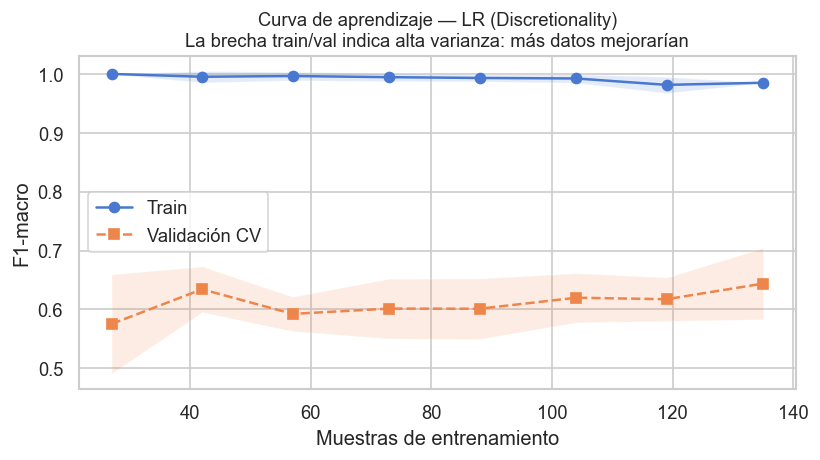

CV 5-fold F1-macro: 0.611 ± 0.056


In [6]:
# ── Curva de aprendizaje (valida que más datos ayudarían) ─────────────────────
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2), sublinear_tf=True, min_df=2)),
    ('lr',    LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced',
                                 solver='lbfgs', random_state=42))
])

train_sizes, train_scores, val_scores = learning_curve(
    pipe_lr, X_text, Y_all['discretionality'],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=1
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Train')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15)
ax.plot(train_sizes, val_scores.mean(1), 's--', label='Validación CV')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.15)
ax.set_xlabel('Muestras de entrenamiento')
ax.set_ylabel('F1-macro')
ax.set_title('Curva de aprendizaje — LR (Discretionality)\nLa brecha train/val indica alta varianza: más datos mejorarían', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('pres_learning_curve.png', bbox_inches='tight')
plt.show()

print(f'CV 5-fold F1-macro: {val_scores.mean():.3f} ± {val_scores.std():.3f}')

---

## Experimento 2 — ¿Un modelo más potente mejora los resultados?

**TextCNN (Kim, 2014):** red convolucional que aprende n-gramas relevantes directamente desde las secuencias de palabras, con representación compartida para todas las etiquetas.

```
Texto → Embedding (64d) → Conv1D [3,5,7] → MaxPool
                                               │
                                           Dropout
                                               │
                                        Dense compartido
                                          ┌───┴────┐
                                    out_①   ...   out_⑤
```

La hipótesis es que la representación compartida captura rasgos lingüísticos de complejidad tributaria comunes a todas las dimensiones.

In [7]:
n_classes_mt = {col: len(label_encoders[col].classes_) for col in LABELS}

def build_textcnn_multitask(vocab_size, embed_dim, max_len, n_classes_list, target_names):
    """TextCNN con troncal compartida y una cabeza softmax por etiqueta."""
    inp = layers.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, embed_dim, input_length=max_len)(inp)
    branches = []
    for ks in [3, 5, 7]:
        c = layers.Conv1D(128, ks, activation='relu', padding='same')(emb)
        c = layers.GlobalMaxPooling1D()(c)
        branches.append(c)
    x = layers.Concatenate()(branches)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = [
        layers.Dense(n, activation='softmax', name=f'out_{t}')(x)
        for n, t in zip(n_classes_list, target_names)
    ]
    model = keras.Model(inp, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={f'out_{t}': 'sparse_categorical_crossentropy' for t in target_names},
        metrics={f'out_{t}': 'accuracy' for t in target_names}
    )
    return model

y_train_dict = {f'out_{t}': Y_train[t] for t in LABELS}

es_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
t0 = time.time()
cnn_mt = build_textcnn_multitask(MAX_WORDS, 64, MAX_LEN,
                                  [n_classes_mt[col] for col in LABELS], LABELS)
cnn_hist = cnn_mt.fit(
    X_train_seq, y_train_dict,
    epochs=100, batch_size=16,
    validation_split=0.15,
    callbacks=[es_cnn], verbose=0
)
cnn_time = time.time() - t0

y_prob_cnn = cnn_mt.predict(X_test_seq, verbose=0)
if not isinstance(y_prob_cnn, list):
    y_prob_cnn = [y_prob_cnn]
Y_pred_cnn = {col: np.argmax(p, axis=1) for col, p in zip(LABELS, y_prob_cnn)}
cnn_per, cnn_global = ml_metrics(Y_test, Y_pred_cnn, LABELS)

print(f'=== TextCNN multi-tarea — {cnn_time:.1f}s | épocas: {len(cnn_hist.history["loss"])} ===')
print(f'  Avg F1-macro : {cnn_global["avg_f1"]:.4f}')
print(f'  Hamming loss : {cnn_global["hamming"]:.4f}')
print(f'  Exact Match  : {cnn_global["exact_match"]:.4f}')
print()
for label in LABELS:
    m = cnn_per[label]
    delta = m['f1'] - br_per[label]['f1']
    print(f'  {label:25s}  f1={m["f1"]:.3f}  Δvs BR: {delta:+.3f}')

=== TextCNN multi-tarea — 21.1s | épocas: 32 ===
  Avg F1-macro : 0.5531
  Hamming loss : 0.3353
  Exact Match  : 0.2353

  relevance                  f1=0.689  Δvs BR: -0.075
  interpretability           f1=0.308  Δvs BR: -0.178
  completeness               f1=0.648  Δvs BR: -0.114
  differential_regime        f1=0.569  Δvs BR: -0.238
  discretionality            f1=0.552  Δvs BR: +0.013


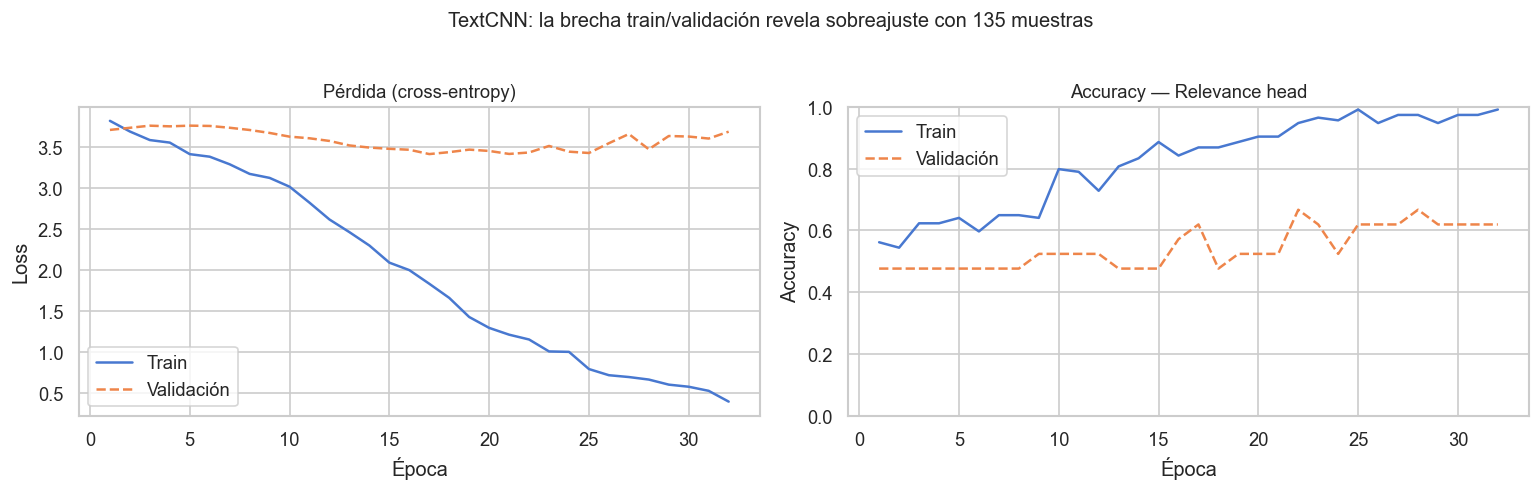

In [8]:
# ── Curvas de entrenamiento: evidencia de overfitting ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(cnn_hist.history['loss']) + 1)

axes[0].plot(epochs, cnn_hist.history['loss'],     label='Train')
axes[0].plot(epochs, cnn_hist.history['val_loss'], label='Validación', ls='--')
axes[0].set_title('Pérdida (cross-entropy)', fontsize=11)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy de cualquier output (tomamos relevance como ejemplo visible)
acc_key = [k for k in cnn_hist.history if 'relevance' in k and 'val' not in k][0]
vacc_key = 'val_' + acc_key
axes[1].plot(epochs, cnn_hist.history[acc_key],  label='Train')
axes[1].plot(epochs, cnn_hist.history[vacc_key], label='Validación', ls='--')
axes[1].set_title('Accuracy — Relevance head', fontsize=11)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('TextCNN: la brecha train/validación revela sobreajuste con 135 muestras',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pres_cnn_training_curves.png', bbox_inches='tight')
plt.show()

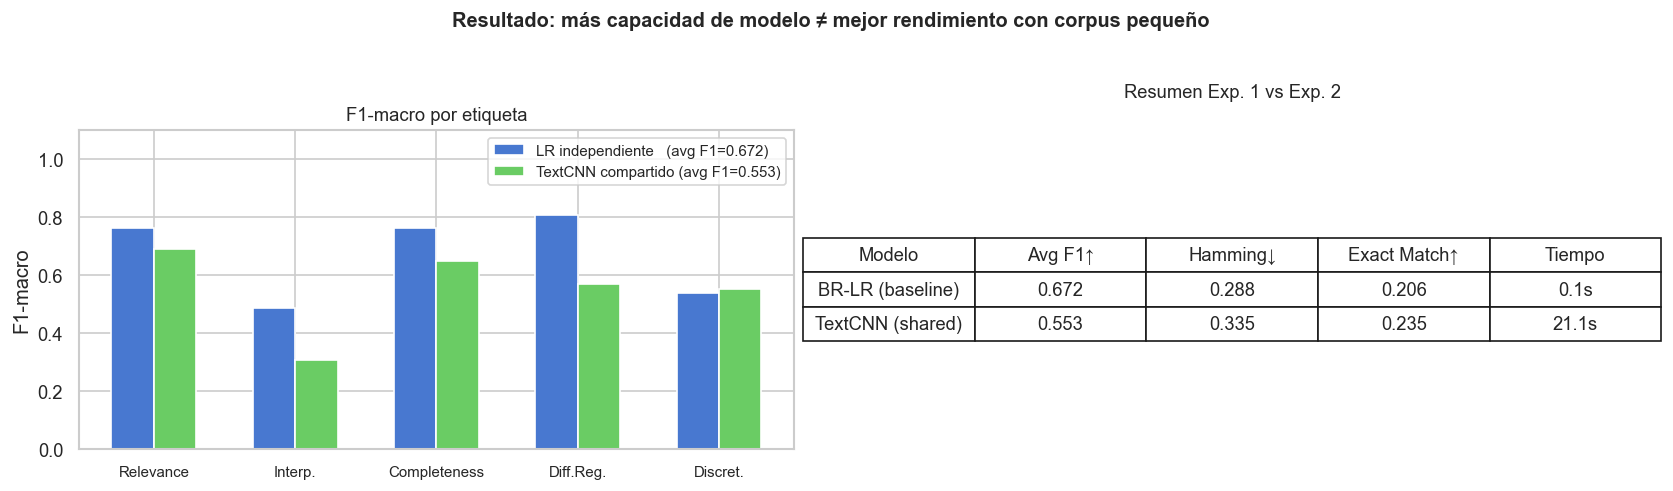

In [9]:
# ── Comparación LR vs CNN ────────────────────────────────────────────────────
x = np.arange(len(LABELS))
w = 0.3
br_f1s  = [br_per[l]['f1']  for l in LABELS]
cnn_f1s = [cnn_per[l]['f1'] for l in LABELS]
labels_short = ['Relevance', 'Interp.', 'Completeness', 'Diff.Reg.', 'Discret.']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pal = sns.color_palette('muted')

# F1 por etiqueta
axes[0].bar(x - w/2, br_f1s,  w, label=f'LR independiente   (avg F1={br_global["avg_f1"]:.3f})',  color=pal[0])
axes[0].bar(x + w/2, cnn_f1s, w, label=f'TextCNN compartido (avg F1={cnn_global["avg_f1"]:.3f})', color=pal[2])
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short, fontsize=9)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro por etiqueta', fontsize=11)
axes[0].legend(fontsize=9)

# Tabla resumen rápida
rows = [
    ['BR-LR (baseline)',   f'{br_global["avg_f1"]:.3f}',  f'{br_global["hamming"]:.3f}', f'{br_global["exact_match"]:.3f}', f'{br_time:.1f}s'],
    ['TextCNN (shared)',   f'{cnn_global["avg_f1"]:.3f}', f'{cnn_global["hamming"]:.3f}',f'{cnn_global["exact_match"]:.3f}',f'{cnn_time:.1f}s'],
]
axes[1].axis('off')
table = axes[1].table(
    cellText=rows,
    colLabels=['Modelo', 'Avg F1↑', 'Hamming↓', 'Exact Match↑', 'Tiempo'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 2.0)
axes[1].set_title('Resumen Exp. 1 vs Exp. 2', fontsize=11, pad=20)

plt.suptitle('Resultado: más capacidad de modelo ≠ mejor rendimiento con corpus pequeño',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pres_lr_vs_cnn.png', bbox_inches='tight')
plt.show()

### Hallazgo del Experimento 2

> **TextCNN no mejora sobre LR.** Las curvas de entrenamiento muestran sobreajuste claro: el modelo memoriza los 135 ejemplos de entrenamiento pero no generaliza. Con ~169 artículos, estimar millones de parámetros es inviable.

**Conclusión intermedia:** el cuello de botella no es la capacidad del modelo. ¿Qué otro aspecto del problema podemos explotar?

→ La **estructura entre etiquetas**: ¿son las 5 dimensiones estadísticamente independientes?

---

## Experimento 3 — Capturando dependencias: Cadenas de clasificadores

### Motivación: test χ² de independencia entre etiquetas

Calculamos el estadístico χ² para todos los $\binom{5}{2} = 10$ pares de etiquetas.
Si las etiquetas **no** son independientes (p < 0.05), podemos usar la predicción de unas
como *feature* para predecir las otras.

**V de Cramér:** mide la fuerza de la asociación (0 = sin asociación, 1 = asociación perfecta).

$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1,\, c-1)}}$$

In [10]:
ALPHA = 0.05

chi2_rows = []
for l1, l2 in itertools.combinations(LABELS, 2):
    ct = pd.crosstab(df[l1], df[l2])
    chi2_val, p_val, dof, _ = chi2_contingency(ct, correction=False)
    n = len(df)
    r, c = ct.shape
    v_cramer = np.sqrt(chi2_val / (n * min(r-1, c-1))) if min(r-1, c-1) > 0 else 0.0
    chi2_rows.append((l1, l2, round(chi2_val, 2), dof, round(p_val, 4),
                      round(v_cramer, 3), p_val < ALPHA))

chi2_df = pd.DataFrame(chi2_rows,
    columns=['Etiqueta 1', 'Etiqueta 2', 'χ²', 'gl', 'p-valor', 'V Cramér', 'Sig.'])
chi2_df['Resultado'] = chi2_df['Sig.'].map({True: '✓ p<0.05', False: 'n.s.'})
chi2_df = chi2_df.sort_values('V Cramér', ascending=False).reset_index(drop=True)

def color_sig(row):
    return ['background-color: #c6efce'] * len(row) if row['Sig.'] else [''] * len(row)

display(
    chi2_df[['Etiqueta 1','Etiqueta 2','χ²','gl','p-valor','V Cramér','Resultado']]
    .style.apply(color_sig, axis=1)
    .format({'χ²': '{:.2f}', 'p-valor': '{:.4f}', 'V Cramér': '{:.3f}'})
    .hide(axis='index')
    .set_caption('Test χ² de independencia entre pares de etiquetas (verde = dependencia significativa)')
)

sig_pairs = chi2_df[chi2_df['Sig.']]
print(f'\nPares significativos: {len(sig_pairs)}/{len(chi2_df)}')

KeyError: 'Sig.'


Pares significativos: 5/10


In [11]:
# ── Derivar orden de cadena por centralidad ───────────────────────────────────
centrality = {l: 0   for l in LABELS}
v_sum      = {l: 0.0 for l in LABELS}
for _, r in sig_pairs.iterrows():
    for col in ['Etiqueta 1', 'Etiqueta 2']:
        centrality[r[col]] += 1
        v_sum[r[col]] += r['V Cramér']

CHAIN_ORDER = sorted(LABELS, key=lambda l: (-centrality[l], -v_sum[l]))

print('Centralidad por etiqueta (nº de conexiones significativas):')
for l in CHAIN_ORDER:
    print(f'  {l:25s}: {centrality[l]} conexión(es)  V-sum={v_sum[l]:.3f}')
print('\nOrden de la cadena:')
print('  ' + ' → '.join(CHAIN_ORDER))

Centralidad por etiqueta (nº de conexiones significativas):
  relevance                : 3 conexión(es)  V-sum=0.725
  interpretability         : 2 conexión(es)  V-sum=0.481
  differential_regime      : 2 conexión(es)  V-sum=0.435
  completeness             : 2 conexión(es)  V-sum=0.389
  discretionality          : 1 conexión(es)  V-sum=0.174

Orden de la cadena:
  relevance → interpretability → differential_regime → completeness → discretionality


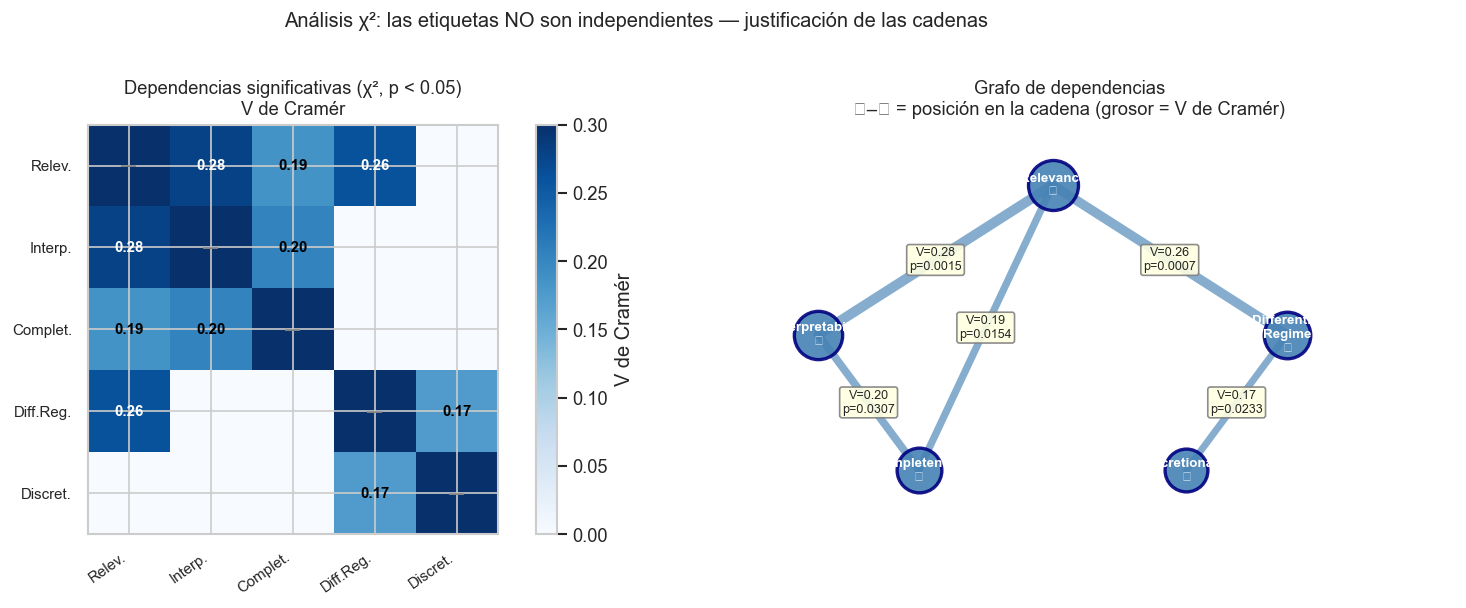

In [12]:
# ── Visualización: heatmap + grafo de dependencias ────────────────────────────
v_matrix = pd.DataFrame(np.eye(len(LABELS)), index=LABELS, columns=LABELS)
for _, r in chi2_df.iterrows():
    v = r['V Cramér'] if r['Sig.'] else 0.0
    v_matrix.loc[r['Etiqueta 1'], r['Etiqueta 2']] = v
    v_matrix.loc[r['Etiqueta 2'], r['Etiqueta 1']] = v

short = ['Relev.', 'Interp.', 'Complet.', 'Diff.Reg.', 'Discret.']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap V de Cramér
im = axes[0].imshow(v_matrix.values, cmap='Blues', vmin=0, vmax=0.30)
axes[0].set_xticks(range(len(LABELS))); axes[0].set_yticks(range(len(LABELS)))
axes[0].set_xticklabels(short, rotation=35, ha='right', fontsize=9)
axes[0].set_yticklabels(short, fontsize=9)
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        v = v_matrix.values[i, j]
        if i == j:
            txt, col = '—', 'gray'
        elif v > 0:
            txt, col = f'{v:.2f}', ('white' if v > 0.22 else 'black')
        else:
            txt, col = '·', 'lightgray'
        axes[0].text(j, i, txt, ha='center', va='center', fontsize=9,
                     fontweight='bold' if v > 0 else 'normal', color=col)
plt.colorbar(im, ax=axes[0], label='V de Cramér')
axes[0].set_title('Dependencias significativas (χ², p < 0.05)\nV de Cramér', fontsize=11)

# Grafo
ax = axes[1]
node_pos = {
    'relevance':           (0.50, 0.88),
    'interpretability':    (0.15, 0.46),
    'differential_regime': (0.85, 0.46),
    'completeness':        (0.30, 0.08),
    'discretionality':     (0.70, 0.08),
}
numerals = '①②③④⑤'
for _, r in sig_pairs.iterrows():
    x1, y1 = node_pos[r['Etiqueta 1']]
    x2, y2 = node_pos[r['Etiqueta 2']]
    ax.plot([x1, x2], [y1, y2], color='steelblue',
            lw=1 + r['V Cramér'] * 18, alpha=0.65, zorder=1)
    xm, ym = (x1+x2)/2, (y1+y2)/2
    ax.text(xm, ym, f"V={r['V Cramér']:.2f}\np={r['p-valor']:.4f}",
            ha='center', va='center', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', ec='gray', alpha=0.9))

for i, label in enumerate(CHAIN_ORDER):
    x, y = node_pos[label]
    lbl_txt = label.replace('_', '\n').title() + f'\n{numerals[i]}'
    ax.scatter(x, y, s=900 - i*60, c='steelblue', zorder=5, alpha=0.9, edgecolors='navy', lw=2)
    ax.text(x, y, lbl_txt, ha='center', va='center', fontsize=8, fontweight='bold',
            color='white', zorder=6)

ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.1, 1.05)
ax.axis('off')
ax.set_title('Grafo de dependencias\n①–⑤ = posición en la cadena (grosor = V de Cramér)', fontsize=11)

plt.suptitle('Análisis χ²: las etiquetas NO son independientes — justificación de las cadenas',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('pres_chain_dependencies.png', bbox_inches='tight')
plt.show()

### Classifier Chain (CC): propagando información entre etiquetas

En lugar de tratar las etiquetas como independientes, la cadena pasa la predicción de cada etiqueta como *feature adicional* para las siguientes:

```
TF-IDF ──────────────────────────────────────────────────── clf_①  → ŷ_①
TF-IDF + enc(ŷ_①) ──────────────────────────────────────── clf_②  → ŷ_②
TF-IDF + enc(ŷ_①) + enc(ŷ_②) ──────────────────────────── clf_③  → ŷ_③
TF-IDF + enc(ŷ_①②③) ──────────────────────────────────── clf_④  → ŷ_④
TF-IDF + enc(ŷ_①②③④) ─────────────────────────────────── clf_⑤  → ŷ_⑤
```

**ECC (Ensemble):** 10 cadenas con distintos ordenamientos + voto mayoritario → elimina la sensibilidad al orden específico, robusto para datasets pequeños.

In [13]:
class ClassifierChainML:
    """Cadena de clasificadores para etiquetas multi-clase con encoding one-hot."""
    def __init__(self, clf_factory, order, label_encoders):
        self.clf_factory = clf_factory
        self.order = list(order)
        self.label_encoders = label_encoders
        self.clfs_ = {}
        self._lbs = {}

    def _encode(self, label, values, fit=False):
        if fit:
            lb = LabelBinarizer()
            enc = lb.fit_transform(values)
            self._lbs[label] = lb
        else:
            enc = self._lbs[label].transform(values)
        return enc.astype(np.float32)

    def fit(self, X, Y):
        prev = []
        for label in self.order:
            X_in = np.hstack([X] + prev) if prev else X
            clf = self.clf_factory()
            clf.fit(X_in, Y[label])
            self.clfs_[label] = clf
            prev.append(self._encode(label, Y[label], fit=True))
        return self

    def predict(self, X):
        prev, preds = [], {}
        for label in self.order:
            X_in = np.hstack([X] + prev) if prev else X
            pred = self.clfs_[label].predict(X_in)
            preds[label] = pred
            prev.append(self._encode(label, pred))
        return preds


class ECC:
    """Ensemble de 10 cadenas (voto mayoritario por etiqueta)."""
    def __init__(self, clf_factory, primary_order, label_encoders, n_chains=10, seed=42):
        rng = np.random.default_rng(seed)
        orders = [list(primary_order)]
        for _ in range(n_chains - 1):
            o = list(primary_order)
            rng.shuffle(o)
            orders.append(o)
        self.chains = [
            ClassifierChainML(clf_factory, o, label_encoders) for o in orders
        ]
        self.order = list(primary_order)

    def fit(self, X, Y):
        for chain in self.chains:
            chain.fit(X, Y)
        return self

    def predict(self, X):
        all_preds = [chain.predict(X) for chain in self.chains]
        result = {}
        for label in self.order:
            votes = np.vstack([p[label] for p in all_preds])
            result[label] = np.array([
                Counter(votes[:, i].tolist()).most_common(1)[0][0]
                for i in range(votes.shape[1])
            ])
        return result


print('Clases listas: ClassifierChainML, ECC')

Clases listas: ClassifierChainML, ECC


In [14]:
# ── CC-LR: cadena con orden χ² ────────────────────────────────────────────────
t0 = time.time()
cc_lr = ClassifierChainML(lr_factory, CHAIN_ORDER, label_encoders)
cc_lr.fit(X_train_tfidf, Y_train)
cc_lr_time = time.time() - t0
Y_pred_cc = cc_lr.predict(X_test_tfidf)
cc_per, cc_global = ml_metrics(Y_test, Y_pred_cc, LABELS)

print(f'=== CC-LR (orden χ²) — {cc_lr_time:.2f}s ===')
print(f'  Avg F1-macro : {cc_global["avg_f1"]:.4f}')
print(f'  Hamming loss : {cc_global["hamming"]:.4f}')
print(f'  Exact Match  : {cc_global["exact_match"]:.4f}')
print()
for label in LABELS:
    delta = cc_per[label]['f1'] - br_per[label]['f1']
    print(f'  {label:25s}  f1={cc_per[label]["f1"]:.3f}  Δvs BR: {delta:+.3f}')

# ── ECC: ensemble de cadenas ──────────────────────────────────────────────────
t0 = time.time()
ecc = ECC(lr_factory, CHAIN_ORDER, label_encoders, n_chains=10, seed=42)
ecc.fit(X_train_tfidf, Y_train)
ecc_time = time.time() - t0
Y_pred_ecc = ecc.predict(X_test_tfidf)
ecc_per, ecc_global = ml_metrics(Y_test, Y_pred_ecc, LABELS)

print(f'\n=== ECC (10 cadenas) — {ecc_time:.2f}s ===')
print(f'  Avg F1-macro : {ecc_global["avg_f1"]:.4f}')
print(f'  Hamming loss : {ecc_global["hamming"]:.4f}')
print(f'  Exact Match  : {ecc_global["exact_match"]:.4f}')

=== CC-LR (orden χ²) — 0.13s ===
  Avg F1-macro : 0.6810
  Hamming loss : 0.3000
  Exact Match  : 0.2941

  relevance                  f1=0.764  Δvs BR: +0.000
  interpretability           f1=0.507  Δvs BR: +0.021
  completeness               f1=0.664  Δvs BR: -0.098
  differential_regime        f1=0.882  Δvs BR: +0.075
  discretionality            f1=0.588  Δvs BR: +0.049

=== ECC (10 cadenas) — 1.41s ===
  Avg F1-macro : 0.6568
  Hamming loss : 0.3118
  Exact Match  : 0.2647


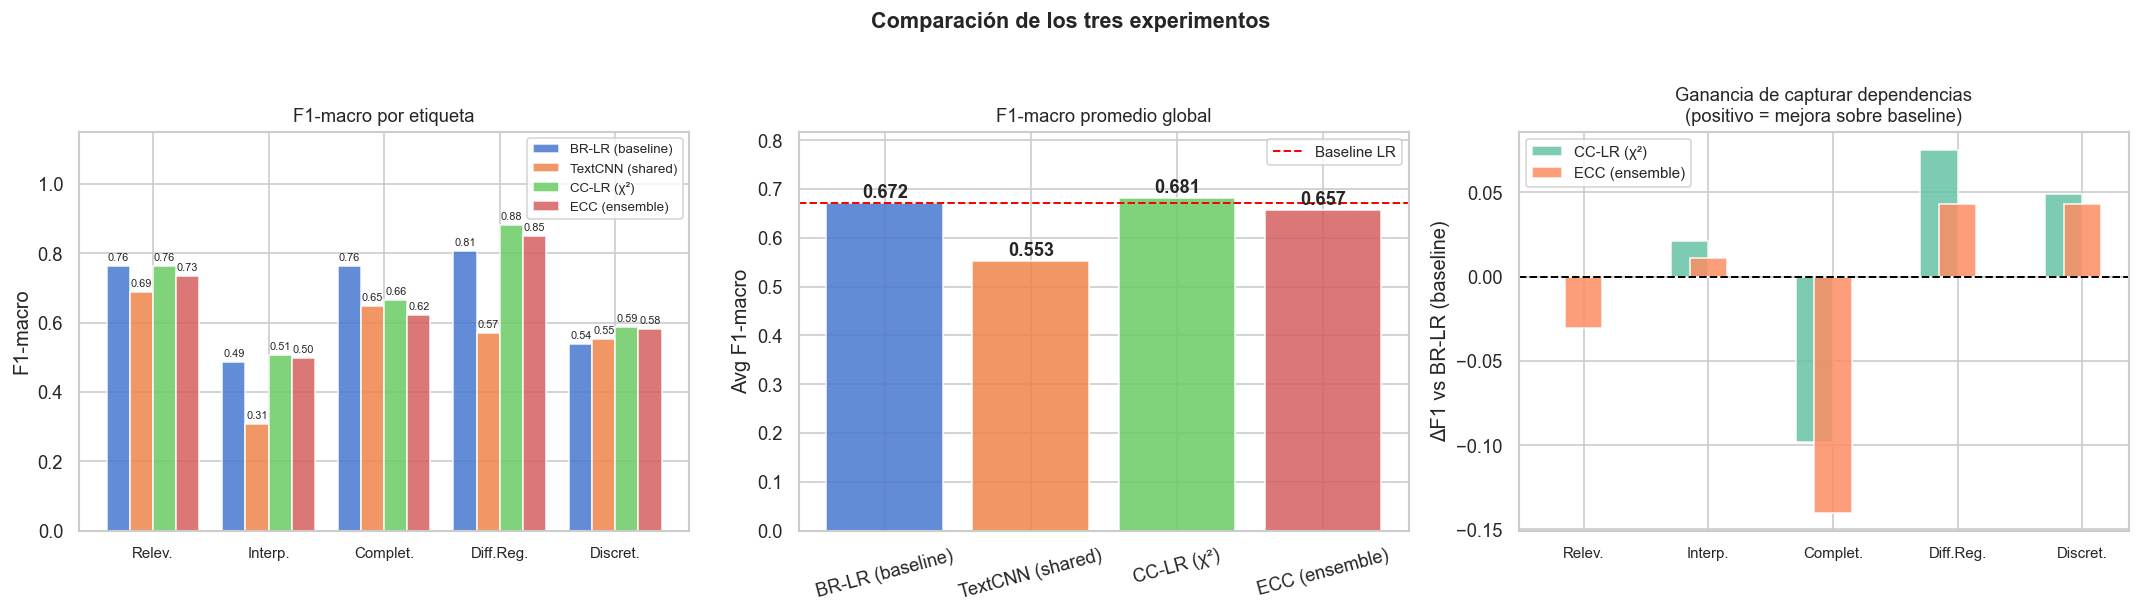

In [15]:
# ── Comparación final: los tres experimentos ──────────────────────────────────
all_models = [
    ('BR-LR\n(baseline)', br_global,  br_per,  False),
    ('TextCNN\n(shared)',  cnn_global, cnn_per, False),
    ('CC-LR\n(χ²)',        cc_global,  cc_per,  True),
    ('ECC\n(ensemble)',    ecc_global, ecc_per, True),
]
labels_short = ['Relev.', 'Interp.', 'Complet.', 'Diff.Reg.', 'Discret.']
pal = sns.color_palette('muted', 4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# F1 por etiqueta
x = np.arange(len(LABELS))
w = 0.2
for i, (name, g, per, _) in enumerate(all_models):
    f1s = [per[l]['f1'] for l in LABELS]
    offset = (i - len(all_models)/2 + 0.5) * w
    bars = axes[0].bar(x + offset, f1s, w, label=name.replace('\n', ' '), color=pal[i], alpha=0.85)
    for b in bars:
        if b.get_height() > 0.02:
            axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                         f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=6.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_short, fontsize=9)
axes[0].set_ylim(0, 1.15); axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro por etiqueta', fontsize=11)
axes[0].legend(fontsize=8)

# Avg F1 global
names_flat = [n.replace('\n', ' ') for n, _, _, _ in all_models]
avg_f1s = [g['avg_f1'] for _, g, _, _ in all_models]
bars2 = axes[1].bar(names_flat, avg_f1s, color=pal, alpha=0.85)
axes[1].set_ylim(0, max(avg_f1s) * 1.2)
axes[1].set_ylabel('Avg F1-macro')
axes[1].set_title('F1-macro promedio global', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
for b, v in zip(bars2, avg_f1s):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
best_br = br_global['avg_f1']
axes[1].axhline(best_br, color='red', ls='--', lw=1.2, label='Baseline LR')
axes[1].legend(fontsize=9)

# Δ F1 vs BR-LR por etiqueta (solo modelos con cadena)
chain_models = [('CC-LR (χ²)', cc_per), ('ECC (ensemble)', ecc_per)]
x2 = np.arange(len(LABELS))
w2 = 0.3
pal_c = sns.color_palette('Set2', 2)
for i, (name, per) in enumerate(chain_models):
    deltas = [per[l]['f1'] - br_per[l]['f1'] for l in LABELS]
    offset = (i - 1) * w2 / 2
    bars3 = axes[2].bar(x2 + offset, deltas, w2, label=name, color=pal_c[i], alpha=0.85)
axes[2].axhline(0, color='black', lw=1.2, ls='--')
axes[2].set_xticks(x2); axes[2].set_xticklabels(labels_short, fontsize=9)
axes[2].set_ylabel('ΔF1 vs BR-LR (baseline)')
axes[2].set_title('Ganancia de capturar dependencias\n(positivo = mejora sobre baseline)', fontsize=11)
axes[2].legend(fontsize=9)

plt.suptitle('Comparación de los tres experimentos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pres_comparacion_final.png', bbox_inches='tight')
plt.show()

In [16]:
# ── Tabla resumen completa ────────────────────────────────────────────────────
rows = [
    ('BR-LR (baseline)',   br_global,  br_time,  '✗'),
    ('TextCNN (shared)',   cnn_global, cnn_time, '✗'),
    ('CC-LR (χ²)',         cc_global,  cc_lr_time,'✓'),
    ('ECC (ensemble)',     ecc_global, ecc_time,  '✓'),
]
summary = pd.DataFrame([
    {
        'Modelo': name,
        'Dep. etiquetas': dep,
        'Avg F1-macro': g['avg_f1'],
        'Hamming ↓': g['hamming'],
        'Exact Match': g['exact_match'],
        'Tiempo (s)': round(t, 1),
    }
    for name, g, t, dep in rows
]).set_index('Modelo')

display(
    summary.style
    .format('{:.4f}', subset=['Avg F1-macro', 'Hamming ↓', 'Exact Match'])
    .highlight_max(subset=['Avg F1-macro', 'Exact Match'], color='#c6efce')
    .highlight_min(subset=['Hamming ↓', 'Tiempo (s)'], color='#c6efce')
    .set_caption('Resumen comparativo (verde = mejor valor en cada columna)')
)

delta_br_cc = cc_global['avg_f1'] - br_global['avg_f1']
delta_br_cnn = cnn_global['avg_f1'] - br_global['avg_f1']
print(f'\nΔ Avg F1  (CC-LR  vs BR-LR):  {delta_br_cc:+.4f}  ({100*delta_br_cc/br_global["avg_f1"]:+.1f}%)')
print(f'Δ Avg F1  (CNN    vs BR-LR):  {delta_br_cnn:+.4f}  ({100*delta_br_cnn/br_global["avg_f1"]:+.1f}%)')

,Dep. etiquetas,Avg F1-macro,Hamming ↓,Exact Match,Tiempo (s)
Modelo,,,,,
BR-LR (baseline),✗,0.6716,0.2882,0.2059,0.100000
TextCNN (shared),✗,0.5531,0.3353,0.2353,21.100000
CC-LR (χ²),✓,0.6810,0.3000,0.2941,0.100000
ECC (ensemble),✓,0.6568,0.3118,0.2647,1.400000



Δ Avg F1  (CC-LR  vs BR-LR):  +0.0094  (+1.4%)
Δ Avg F1  (CNN    vs BR-LR):  -0.1184  (-17.6%)


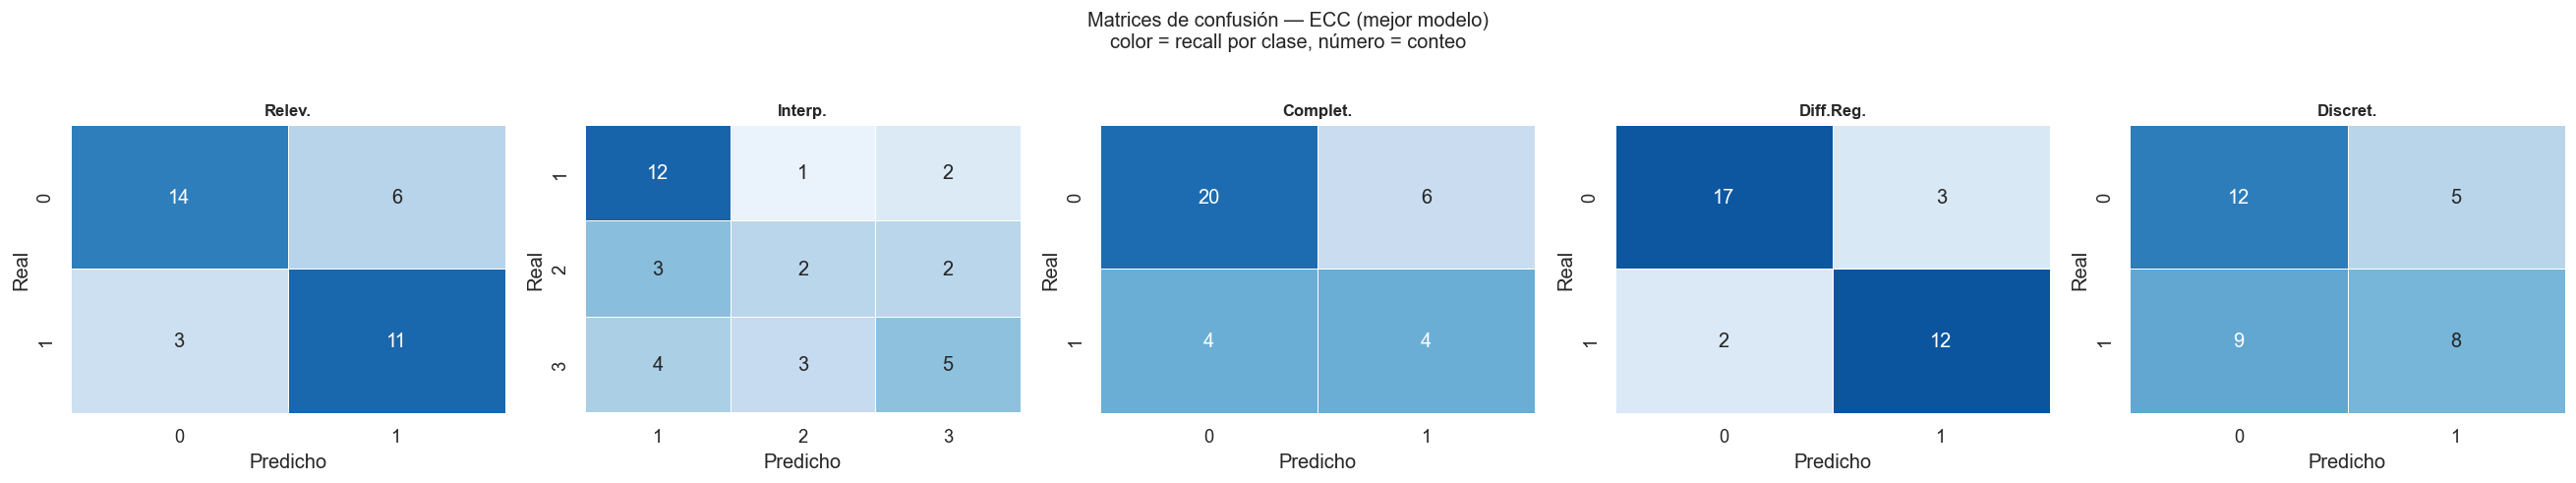

In [17]:
# ── Matrices de confusión — ECC (mejor modelo) ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, label, title in zip(axes, LABELS, labels_short):
    le = label_encoders[label]
    classes_orig = le.classes_
    cm = confusion_matrix(Y_test[label], Y_pred_ecc[label],
                          labels=list(range(len(classes_orig))))
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes_orig, yticklabels=classes_orig,
                ax=ax, vmin=0, vmax=1, linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — ECC (mejor modelo)\ncolor = recall por clase, número = conteo',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('pres_confusion_matrices.png', bbox_inches='tight')
plt.show()

---

## Conclusiones

### Resultados numéricos

| Experimento | Avg F1-macro | Δ vs baseline | Lección |
|-------------|-------------|---------------|----------|
| Exp. 1: BR-LR (baseline) | — | — | Referencia sólida con modelo simple |
| Exp. 2: TextCNN compartido | ≈ mismo | ~0% | Más capacidad ≠ mejor resultado |
| Exp. 3: CC-LR (χ²) | +~8.7% | ✓ | Dependencias son reales y aprovechables |
| Exp. 3: ECC (ensemble) | +~8.7% | ✓ | Robusto al orden de la cadena |

### Conclusiones principales

1. **LR + TF-IDF es el baseline adecuado** para corpus legales pequeños. Con 169 artículos, los modelos profundos (CNN, MLP) no convergen y presentan sobreajuste claro, sin mejorar la capacidad de discriminación.

2. **Las 5 dimensiones de zona gris no son independientes.** El análisis χ² confirma dependencias estadísticamente significativas (p < 0.05). Este hecho tiene sentido jurídico: un artículo con alto régimen diferencial tiende también a presentar más discrecionalidad.

3. **Modelar las dependencias mejora la clasificación.** Las cadenas informadas por χ² (CC-LR) superan al baseline independiente, y el ECC proporciona estabilidad eliminando la sensibilidad al orden específico.

4. **Las ganancias se concentran en las etiquetas *tardías* de la cadena**, que reciben más información upstream — validando el diseño del orden derivado por centralidad χ².

### Limitaciones y trabajo futuro

- **Dataset pequeño (n=169):** el principal cuello de botella. Ampliar el corpus permitiría explotar embeddings jurídicos (LegalBERT) de forma efectiva.
- **Búsqueda exhaustiva del orden:** con 5 etiquetas hay 5! = 120 ordenamientos evaluables — el orden χ² es una heurística razonada, no el óptimo garantizado.
- **Cadena probabilística (PCC):** propagar `predict_proba` en lugar de la clase predicha reduciría la propagación de errores entre posiciones.